## Importing the libraries

In [331]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## Looking at the dataset

In [332]:
data = pd.read_csv(r'cleaned_excel.csv')
data.head()

,TransactionID,CustomerID,PurchaseDate,Product,Category,Quantity,UnitPrice,City,Gender,Age
0,1,CUST2620,24-04-2024,Dress,Women'S Wear,2,1442.0,Mumbai,Female,65
1,1,CUST2620,24-04-2024,Handbag,Accessories,2,3978.0,Bangalore,Male,55
2,2,CUST1409,10-09-2025,Jeans,Bottomwear,1,4821.0,Bangalore,Male,36
3,2,CUST1409,10-09-2025,Belt,Accessories,3,4013.0,Bangalore,Female,58
4,2,CUST1409,10-09-2025,Shorts,Bottomwear,3,4861.0,Mumbai,Male,32


## Detecting the outliers

In [333]:
cols = ['Quantity','UnitPrice','Age']

for i in cols:
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    print(f"\n{i}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")

    outliers = data[(data[i] < lower_bound) | (data[i] > upper_bound)]
    print(f"Number of outliers: {len(outliers)}")

    median_value = data[i].median()
    data.loc[data[i] < lower_bound, i] = median_value
    data.loc[data[i] > upper_bound, i] = median_value


Quantity
Lower bound: -1.0
Upper bound: 7.0
Number of outliers: 145

UnitPrice
Lower bound: -2025.625
Upper bound: 7287.375
Number of outliers: 103

Age
Lower bound: -4.5
Upper bound: 87.5
Number of outliers: 22


In [334]:
for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((data[col] < lower) | (data[col] > upper)).sum()

    print(f"{col}: {count} outliers remaining")

Quantity: 0 outliers remaining
UnitPrice: 0 outliers remaining
Age: 0 outliers remaining


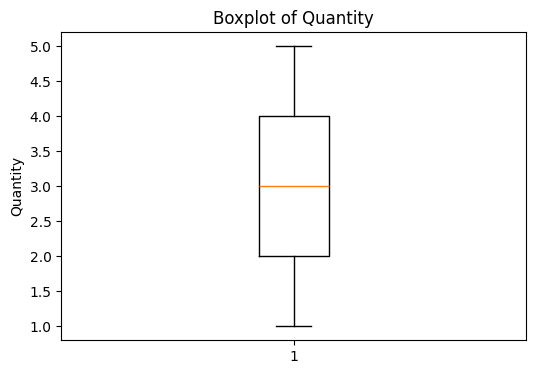

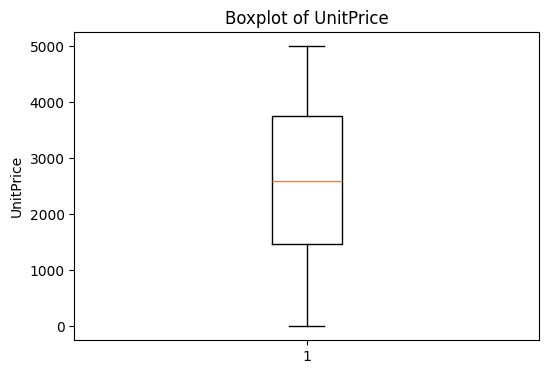

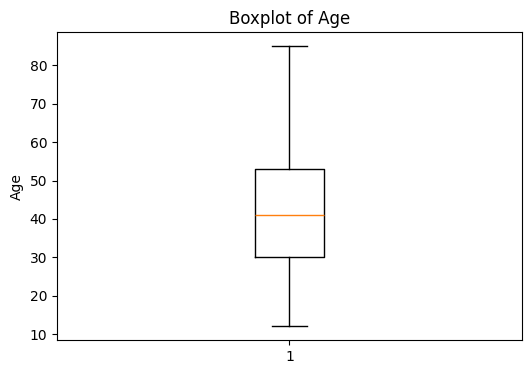

In [335]:
for col in ['Quantity', 'UnitPrice', 'Age']:
    plt.figure(figsize=(6, 4))
    plt.boxplot(data[col].dropna())

    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

    plt.show()

## Normalizing the data

In [336]:
cols = ['Quantity', 'UnitPrice', 'Age']

for i in cols:
    min_value = data[i].min()
    max_value = data[i].max()

    data[i + '_Norm'] = (data[i] - min_value)/(max_value - min_value)

print(data.head())

   TransactionID CustomerID PurchaseDate  Product      Category  Quantity  \
0              1   CUST2620   24-04-2024    Dress  Women'S Wear         2   
1              1   CUST2620   24-04-2024  Handbag   Accessories         2   
2              2   CUST1409   10-09-2025    Jeans    Bottomwear         1   
3              2   CUST1409   10-09-2025     Belt   Accessories         3   
4              2   CUST1409   10-09-2025   Shorts    Bottomwear         3   

   UnitPrice       City  Gender  Age  Quantity_Norm  UnitPrice_Norm  Age_Norm  
0     1442.0     Mumbai  Female   65           0.25        0.288515  0.726027  
1     3978.0  Bangalore    Male   55           0.25        0.795918  0.589041  
2     4821.0  Bangalore    Male   36           0.00        0.964586  0.328767  
3     4013.0  Bangalore  Female   58           0.50        0.802921  0.630137  
4     4861.0     Mumbai    Male   32           0.50        0.972589  0.273973  


## Product Analysis

In [337]:
print("Unique Products:",data['Product'].nunique())

print("\nCount of each product:")
print(data["Product"].value_counts())

print("\nCustomer getting how many products (only 5):")
print(data.groupby('CustomerID')['Product'].nunique().head())

print("\nCustomer getting what products (only 5):")
print(data.groupby('CustomerID')['Product'].apply(list).head())

Unique Products: 16

Count of each product:
Product
Jacket      1122
Dress       1114
Scarf       1103
Belt        1097
Sneakers    1097
Socks       1095
Handbag     1088
Hoodie      1067
Shirt       1057
Tie         1050
Cap         1042
Jeans       1031
Skirt        555
Shorts       504
Watch        490
T-Shirt      488
Name: count, dtype: int64

Customer getting how many products (only 5):
CustomerID
CUST0001    5
CUST0002    4
CUST0004    5
CUST0005    5
CUST0007    2
Name: Product, dtype: int64

Customer getting what products (only 5):
CustomerID
CUST0001     [Sneakers, Socks, Dress, Dress, Handbag, Shorts]
CUST0002    [Dress, Handbag, Scarf, Socks, Dress, Handbag,...
CUST0004               [Jacket, Scarf, Socks, Dress, Handbag]
CUST0005                    [Jeans, Belt, Jacket, Scarf, Tie]
CUST0007                                        [Skirt, Belt]
Name: Product, dtype: object


## Removing the duplicated list

In [338]:
transactions = data.groupby('TransactionID')['Product'].apply(lambda x: list(set(x))).tolist()
print("Transactions (only 10):")
print(transactions[:10])

Transactions (only 10):
[['Handbag', 'Dress'], ['Shorts', 'Sneakers', 'Jeans', 'Belt'], ['Sneakers', 'Socks', 'Watch', 'T-Shirt'], ['Cap', 'Jeans', 'Belt'], ['Tie', 'Shirt'], ['Cap', 'Jeans', 'Belt'], ['Skirt', 'Handbag', 'Dress'], ['Jacket', 'Scarf'], ['Socks', 'Hoodie', 'Watch', 'Belt'], ['Socks', 'Hoodie']]


## Transaction Encoding

In [339]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)
print(basket.head())

    Belt    Cap  Dress  Handbag  Hoodie  Jacket  Jeans  Scarf  Shirt  Shorts  \
0  False  False   True     True   False   False  False  False  False   False   
1   True  False  False    False   False   False   True  False  False    True   
2  False  False  False    False   False   False  False  False  False   False   
3   True   True  False    False   False   False   True  False  False   False   
4  False  False  False    False   False   False  False  False   True   False   

   Skirt  Sneakers  Socks  T-Shirt    Tie  Watch  
0  False     False  False    False  False  False  
1  False      True  False    False  False  False  
2  False      True   True     True  False   True  
3  False     False  False    False  False  False  
4  False     False  False    False   True  False  


## Frequent Pattern Growth

In [340]:
frequent_items = fpgrowth(basket, min_support=0.05, use_colnames=True)
print(frequent_items.sort_values(by='support', ascending=False))

    support                      itemsets
13   0.2072           frozenset({Jacket})
0    0.2050            frozenset({Dress})
2    0.2032         frozenset({Sneakers})
3    0.2026             frozenset({Belt})
14   0.2026            frozenset({Scarf})
1    0.2020          frozenset({Handbag})
6    0.1988            frozenset({Socks})
15   0.1980           frozenset({Hoodie})
10   0.1968            frozenset({Shirt})
11   0.1938              frozenset({Tie})
4    0.1908            frozenset({Jeans})
9    0.1902              frozenset({Cap})
21   0.1322    frozenset({Jacket, Scarf})
18   0.1262  frozenset({Sneakers, Socks})
19   0.1242      frozenset({Cap, Hoodie})
16   0.1226   frozenset({Handbag, Dress})
17   0.1220      frozenset({Jeans, Belt})
20   0.1194       frozenset({Tie, Shirt})
12   0.1006            frozenset({Skirt})
5    0.0910           frozenset({Shorts})
7    0.0902            frozenset({Watch})
8    0.0894          frozenset({T-Shirt})


## Association Rules

In [341]:
rules = association_rules(frequent_items, metric='confidence', min_threshold=0.5)

rules = rules.sort_values(
    by='confidence',
    ascending=False
)

print("\nTop 10 Rules")

print(rules[[
            'antecedents',
            'consequents',
            'support',
            'confidence',
            'lift'
]].head(10))


Top 10 Rules
              antecedents            consequents  support  confidence  \
6        frozenset({Cap})    frozenset({Hoodie})   0.1242    0.652997   
11     frozenset({Scarf})    frozenset({Jacket})   0.1322    0.652517   
2      frozenset({Jeans})      frozenset({Belt})   0.1220    0.639413   
10    frozenset({Jacket})     frozenset({Scarf})   0.1322    0.638031   
5      frozenset({Socks})  frozenset({Sneakers})   0.1262    0.634809   
7     frozenset({Hoodie})       frozenset({Cap})   0.1242    0.627273   
4   frozenset({Sneakers})     frozenset({Socks})   0.1262    0.621063   
8        frozenset({Tie})     frozenset({Shirt})   0.1194    0.616099   
0    frozenset({Handbag})     frozenset({Dress})   0.1226    0.606931   
9      frozenset({Shirt})       frozenset({Tie})   0.1194    0.606707   

        lift  
6   3.297964  
11  3.149215  
2   3.156037  
10  3.149215  
5   3.124059  
7   3.297964  
4   3.124059  
8   3.130585  
0   2.960638  
9   3.130585  


In [342]:
top_rules = rules.sort_values(by='lift',ascending=False)

print(top_rules[[
              'antecedents',
              'consequents',
              'support',
              'confidence',
              'lift'
]])

              antecedents            consequents  support  confidence  \
6        frozenset({Cap})    frozenset({Hoodie})   0.1242    0.652997   
7     frozenset({Hoodie})       frozenset({Cap})   0.1242    0.627273   
3       frozenset({Belt})     frozenset({Jeans})   0.1220    0.602172   
2      frozenset({Jeans})      frozenset({Belt})   0.1220    0.639413   
10    frozenset({Jacket})     frozenset({Scarf})   0.1322    0.638031   
11     frozenset({Scarf})    frozenset({Jacket})   0.1322    0.652517   
9      frozenset({Shirt})       frozenset({Tie})   0.1194    0.606707   
8        frozenset({Tie})     frozenset({Shirt})   0.1194    0.616099   
4   frozenset({Sneakers})     frozenset({Socks})   0.1262    0.621063   
5      frozenset({Socks})  frozenset({Sneakers})   0.1262    0.634809   
1      frozenset({Dress})   frozenset({Handbag})   0.1226    0.598049   
0    frozenset({Handbag})     frozenset({Dress})   0.1226    0.606931   

        lift  
6   3.297964  
7   3.297964  
3   3

## Product Pairs

In [343]:
pairs = frequent_items[frequent_items['itemsets'].apply(len) == 2]

pairs = pairs.sort_values(by='support',ascending=False)

print("Most Frequent Product Pairs")
print(pairs)

Most Frequent Product Pairs
    support                      itemsets
21   0.1322    frozenset({Jacket, Scarf})
18   0.1262  frozenset({Sneakers, Socks})
19   0.1242      frozenset({Cap, Hoodie})
16   0.1226   frozenset({Handbag, Dress})
17   0.1220      frozenset({Jeans, Belt})
20   0.1194       frozenset({Tie, Shirt})


## Business Insights

In [344]:
print("Business Insights\n")
for index, row in top_rules.iterrows():
    print(f"If customer buys "
        f"{set(row['antecedents'])}, "
        f"they are likely to buy "
        f"{set(row['consequents'])}"
    )
    print(f"Support : {row['support']:.2f}")
    print(f"Confidence : {row['confidence']:.2f}")
    print(f"Lift : {row['lift']:.2f}")
    print("-" * 60)

Business Insights

If customer buys {'Cap'}, they are likely to buy {'Hoodie'}
Support : 0.12
Confidence : 0.65
Lift : 3.30
------------------------------------------------------------
If customer buys {'Hoodie'}, they are likely to buy {'Cap'}
Support : 0.12
Confidence : 0.63
Lift : 3.30
------------------------------------------------------------
If customer buys {'Belt'}, they are likely to buy {'Jeans'}
Support : 0.12
Confidence : 0.60
Lift : 3.16
------------------------------------------------------------
If customer buys {'Jeans'}, they are likely to buy {'Belt'}
Support : 0.12
Confidence : 0.64
Lift : 3.16
------------------------------------------------------------
If customer buys {'Jacket'}, they are likely to buy {'Scarf'}
Support : 0.13
Confidence : 0.64
Lift : 3.15
------------------------------------------------------------
If customer buys {'Scarf'}, they are likely to buy {'Jacket'}
Support : 0.13
Confidence : 0.65
Lift : 3.15
------------------------------------------

## Saving the Rules

In [345]:
rules.to_csv('association_rules.csv',index=False)
print("\nAssociation Rules Saved Successfully")


Association Rules Saved Successfully


## K means

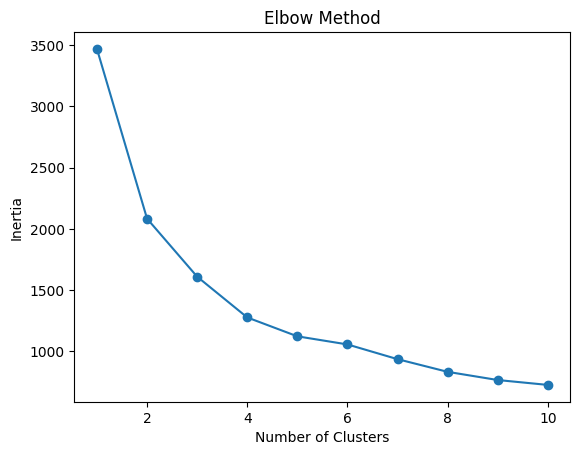

In [346]:
inertia = []
X = data[['Quantity_Norm','UnitPrice_Norm','Age_Norm']]

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [347]:
X = data[['Quantity_Norm','UnitPrice_Norm','Age_Norm']]

kmeans = KMeans(n_clusters=3, random_state=42)
data['Clusters'] = kmeans.fit_predict(X)

print(data[['Quantity','UnitPrice','Age','Clusters']].head())
print(data['Clusters'].value_counts())

   Quantity  UnitPrice  Age  Clusters
0         2     1442.0   65         2
1         2     3978.0   55         1
2         1     4821.0   36         1
3         3     4013.0   58         1
4         3     4861.0   32         1
Clusters
0    6000
2    4880
1    4120
Name: count, dtype: int64


In [348]:
cluster_summary = data.groupby('Clusters')[['Quantity','UnitPrice','Age']].mean()
print(cluster_summary)

          Quantity    UnitPrice        Age
Clusters                                  
0         4.501500  2613.255000  41.163833
1         2.037864  3840.911408  41.014320
2         1.997131  1549.592623  41.733402


## Save the data

In [349]:
data.to_csv(r'cleaned_excel.csv', index=False)